# 02 · EDA — Main Table (`application_train`)

**Project:** Credit Default Risk — AI Governance Portfolio (Notebook 2 of the pipeline)

---

## Goal

Notebook 01 inventoried the data and registered the protected attributes. Here we do a
focused **exploratory analysis of the main table** to answer four questions that drive
both the model *and* the Fair Lending audit:

1. **Which features actually separate defaulters from non-defaulters?** (correlation ranking)
2. **The `EXT_SOURCE` scores** — the strongest predictors — what are they and how missing are they?
3. **Data-quality landmines** that will break a naive model (esp. the `DAYS_EMPLOYED` sentinel).
4. ⭐ **Do default rates differ across the protected groups?** — the first quantitative
   signal of potential disparate impact, carried into the fairness audit (`05`).

Every default rate we compute here is a *baseline in the raw data* (before any modeling),
which is exactly what a Fair Lending review needs as its reference point.


## 0 · Setup

In [1]:
import os                       # OS-independent file paths
import warnings                  # silence non-actionable warnings
import numpy as np               # numerical arrays
import pandas as pd              # dataframes

import matplotlib.pyplot as plt  # base plotting
import seaborn as sns            # statistical charts

pd.set_option("display.max_columns", 200)   # don't truncate wide tables
sns.set_theme(style="whitegrid")            # clean chart style
warnings.filterwarnings("ignore")           # keep output readable

DATA_DIR = "../data"             # raw CSVs
RESULTS_DIR = "../results"       # save figures here
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load the main table (the only one this notebook analyzes).
app = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
print("application_train:", app.shape)
print("Overall default rate:", f"{app['TARGET'].mean()*100:.2f}%")

application_train: (307511, 122)
Overall default rate: 8.07%


## 1 · Which numeric features separate defaulters?

A quick, honest first pass: the **linear correlation** of each numeric feature with
`TARGET`. Correlations are weak in credit data (no single feature decides default), so we
read the **ranking and direction**, not the absolute size.
- **Negative** correlation → higher value, *lower* default risk (protective).
- **Positive** correlation → higher value, *higher* default risk.


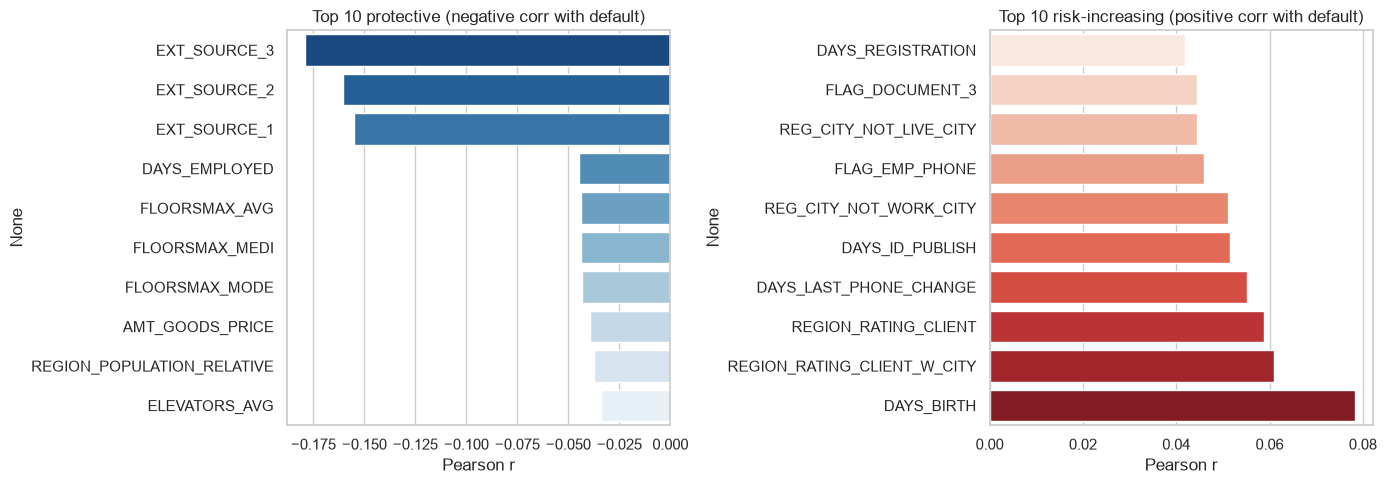

In [2]:
# Correlation of every numeric column with TARGET (drop TARGET's self-correlation).
numeric = app.select_dtypes("number")                       # numeric columns only
corr_target = numeric.corrwith(app["TARGET"]).drop("TARGET").sort_values()

# The 10 most protective (negative) and 10 highest-risk (positive) features.
most_protective = corr_target.head(10)
most_risk = corr_target.tail(10)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=most_protective.values, y=most_protective.index, ax=ax[0], palette="Blues_r")
ax[0].set_title("Top 10 protective (negative corr with default)")
ax[0].set_xlabel("Pearson r")
sns.barplot(x=most_risk.values, y=most_risk.index, ax=ax[1], palette="Reds")
ax[1].set_title("Top 10 risk-increasing (positive corr with default)")
ax[1].set_xlabel("Pearson r")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "02_corr_with_target.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.**
- The **three `EXT_SOURCE` scores** dominate the protective side (r ≈ −0.18, −0.16, −0.16) —
  by far the strongest signals in the table. We deep-dive them in §2.
- On the risk side, the strongest features are **region/city ratings** and several `DAYS_*`
  fields — notably **`DAYS_BIRTH`** (r ≈ +0.08): *younger applicants default more*. Because
  age is a **prohibited basis (ECOA)**, this is flagged for the fairness audit, not just used.
- All correlations are small (|r| < 0.2) → a **non-linear model** (XGBoost) and good
  feature engineering will matter more than any single column.


## 2 · The `EXT_SOURCE` scores — the headline predictors

`EXT_SOURCE_1/2/3` are **normalized scores from external data sources** (other credit
bureaus / scoring providers), already scaled to roughly [0, 1]. They are the most
predictive features — but also partly missing, which creates a governance trade-off:
*too valuable to drop, so they must be imputed carefully (and the imputation documented).*


EXT_SOURCE summary:
  EXT_SOURCE_1: missing 56.4% | mean repaid 0.511 vs default 0.387
  EXT_SOURCE_2: missing  0.2% | mean repaid 0.523 vs default 0.411
  EXT_SOURCE_3: missing 19.8% | mean repaid 0.521 vs default 0.391


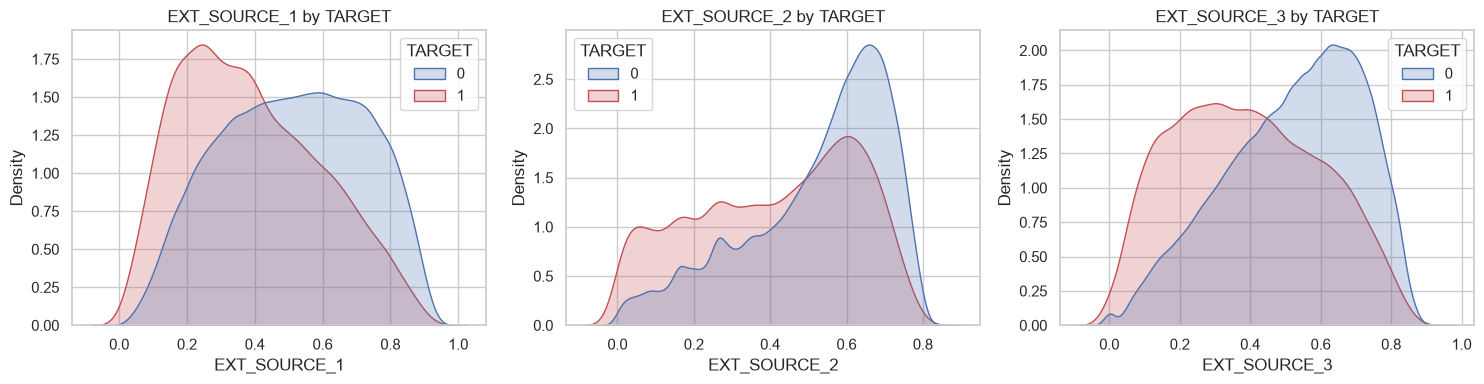

In [3]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

# How missing is each, and does the score differ between repaid vs default?
print("EXT_SOURCE summary:")
for c in ext_cols:
    miss = app[c].isna().mean() * 100                       # % missing
    mean_repaid = app.loc[app["TARGET"] == 0, c].mean()     # avg score for repaid
    mean_default = app.loc[app["TARGET"] == 1, c].mean()    # avg score for default
    print(f"  {c}: missing {miss:4.1f}% | mean repaid {mean_repaid:.3f} vs default {mean_default:.3f}")

# Visualize the score distributions split by TARGET — separation = predictive power.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, ext_cols):
    sns.kdeplot(data=app, x=c, hue="TARGET", common_norm=False, fill=True,
                palette={0: "#4C72B0", 1: "#C44E52"}, ax=ax)
    ax.set_title(f"{c} by TARGET")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "02_ext_source_by_target.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.**
- For all three, **defaulters score lower** (e.g. `EXT_SOURCE_3`: 0.521 repaid vs 0.391
  default) and the curves visibly separate — these are genuine signals.
- **Missingness varies sharply:** `EXT_SOURCE_2` ~0.2% (essentially complete),
  `EXT_SOURCE_3` ~20%, **`EXT_SOURCE_1` ~56%** (more than half missing).
- **Plan for `03`:** keep all three, impute (median), and add a **"was-missing" flag** so the
  model can use missingness itself as a signal — and check that missingness is not
  concentrated in a protected group (which would make imputation a bias vector).


## 3 · Data-quality landmines

Raw credit data hides sentinels and impossible values that silently corrupt a model. We
catch the big ones here so `03` can fix them deliberately (and document the fix).


DAYS_EMPLOYED max: 365243 (= 1001 years — impossible)
Rows with sentinel 365243: 55,374 (18.0% of data)
Default rate WHERE sentinel: 5.40% | elsewhere: 8.66%


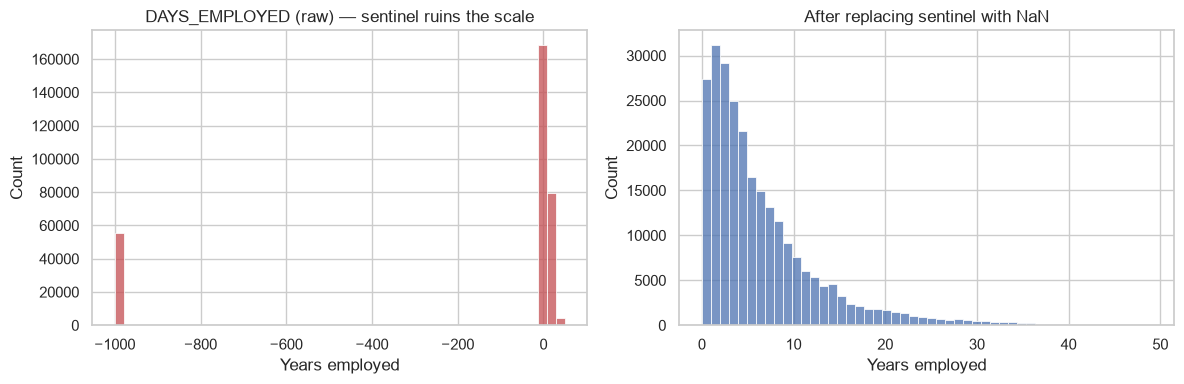

In [4]:
# (a) DAYS_EMPLOYED — known sentinel value 365243 (~1000 years) used as a placeholder.
de = app["DAYS_EMPLOYED"]
sentinel = 365243
n_sent = (de == sentinel).sum()
print("DAYS_EMPLOYED max:", de.max(), "(=", round(de.max()/365), "years — impossible)")
print(f"Rows with sentinel {sentinel}: {n_sent:,} ({n_sent/len(app)*100:.1f}% of data)")
print("Default rate WHERE sentinel:", f"{app.loc[de == sentinel, 'TARGET'].mean()*100:.2f}%",
      "| elsewhere:", f"{app.loc[de != sentinel, 'TARGET'].mean()*100:.2f}%")

# (b) Show the distribution before vs after replacing the sentinel with NaN.
employed_years_raw = de / -365.25                            # convert to years (sign flip); sentinel becomes ~ -1000
de_clean = de.replace(sentinel, np.nan)                      # the fix: sentinel -> missing
employed_years_clean = de_clean / -365.25

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(employed_years_raw, bins=50, ax=ax[0], color="#C44E52")
ax[0].set_title("DAYS_EMPLOYED (raw) — sentinel ruins the scale")
ax[0].set_xlabel("Years employed")
sns.histplot(employed_years_clean.dropna(), bins=50, ax=ax[1], color="#4C72B0")
ax[1].set_title("After replacing sentinel with NaN")
ax[1].set_xlabel("Years employed")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "02_days_employed_sentinel.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.**
- **18.0%** of rows carry the `DAYS_EMPLOYED = 365243` sentinel. These are almost all
  **pensioners / unemployed** (no employment to report), and they default *less* (5.4% vs
  8.7%) — so the sentinel is **not random**; dropping or mis-imputing it would distort the model.
- **Fix in `03`:** replace 365243 with `NaN` **and** add a flag `DAYS_EMPLOYED_ANOMALY` so
  the "no employment record" signal is preserved rather than thrown away.
- We also reconfirm the `CODE_GENDER = XNA` (4 rows) and `NAME_FAMILY_STATUS = Unknown`
  (2 rows) issues from `01` — tiny, but they must be resolved before fairness slicing.


## 4 · Categorical features vs default rate

For categorical fields we compare the **default rate within each category** against the
**8.07% overall baseline**. A category far from the baseline carries signal — and if that
category is a protected attribute, it is also a fairness flag.


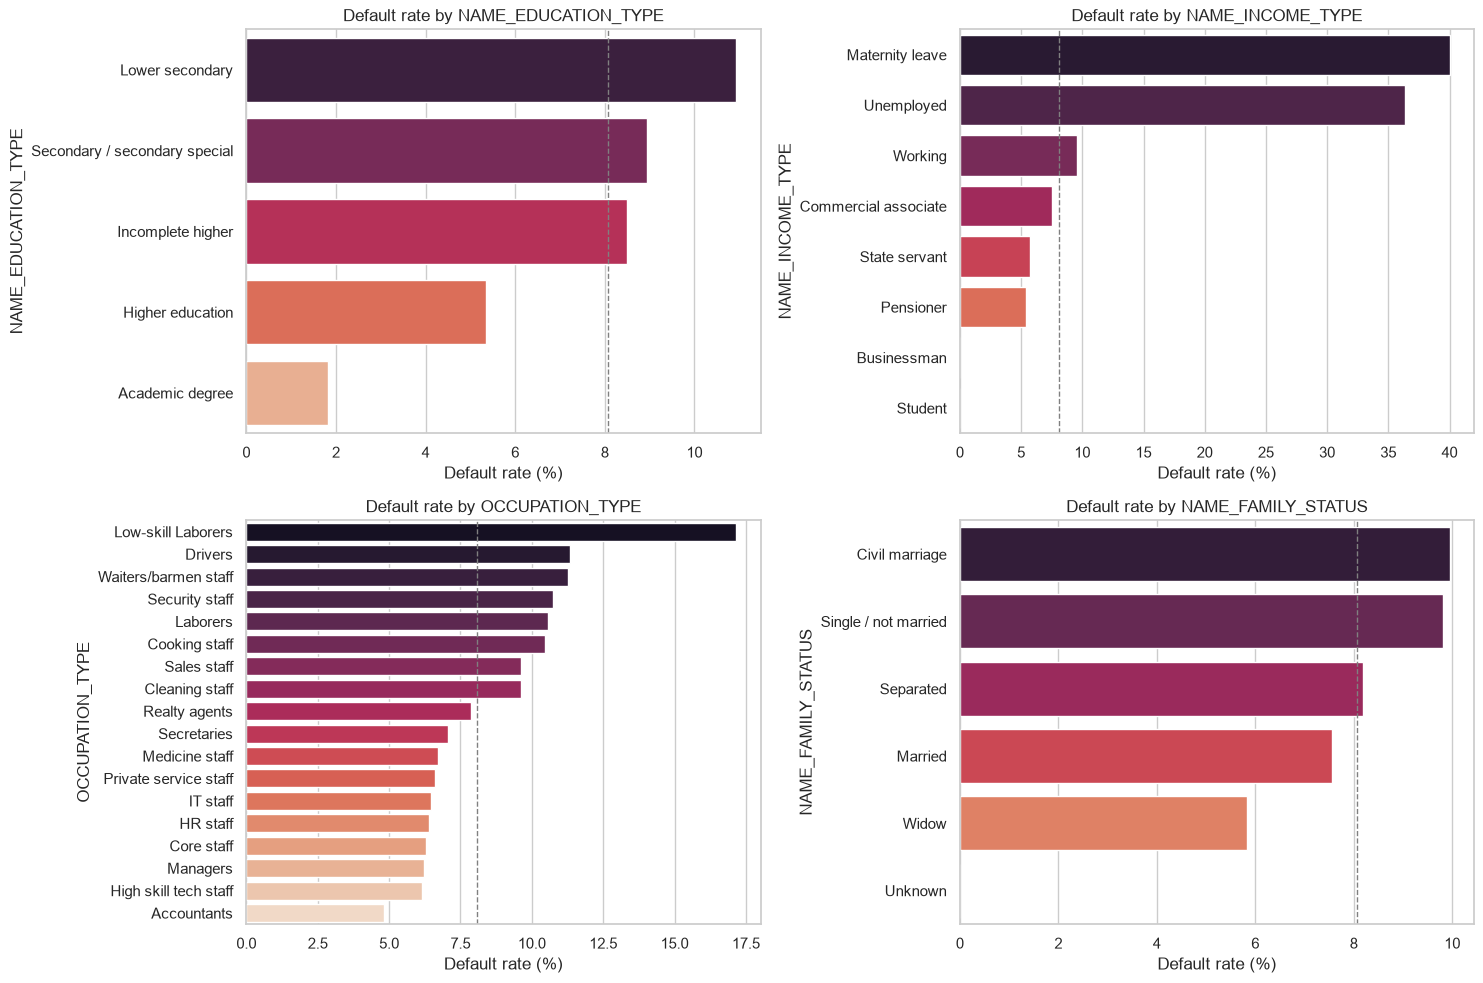

In [5]:
baseline = app["TARGET"].mean() * 100                       # 8.07% reference line

# Helper: default rate (%) and size per category, sorted high -> low.
def default_rate_table(col):
    g = app.groupby(col)["TARGET"].agg(rate="mean", n="size")
    g["rate"] = g["rate"] * 100
    return g.sort_values("rate", ascending=False)

cat_cols = ["NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE", "OCCUPATION_TYPE", "NAME_FAMILY_STATUS"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.ravel(), cat_cols):
    tbl = default_rate_table(col)
    sns.barplot(x=tbl["rate"], y=tbl.index, ax=ax, palette="rocket")
    ax.axvline(baseline, color="gray", linestyle="--", linewidth=1)   # 8.07% baseline
    ax.set_title(f"Default rate by {col}")
    ax.set_xlabel("Default rate (%)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "02_categorical_default_rates.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.**
- **Education** shows a clean gradient: *Lower secondary* **10.9%** → *Academic degree*
  **1.8%**. Education is a recognized **disparate-impact proxy**, so this gradient is a
  prime audit target.
- **Income type:** *Working* defaults most among large groups (9.6%); *Pensioner* /
  *State servant* lowest. Tiny groups (*Maternity leave* n=5 at 40%, *Student* n=18 at 0%)
  are **too small to trust** — a reminder that subgroup metrics need minimum-sample guards.
- **Family status** (a protected attribute): *Civil marriage* (9.9%) and *Single* (9.8%) sit
  well above *Married* (7.6%) and *Widow* (5.8%) — carried into the fairness audit.


## 5 · ⭐ Baseline default rates across protected groups

This is the EDA step that directly feeds the Fair Lending audit. We compute the
**raw default rate within each protected group** — the *pre-model* disparity. The audit in
`05` will later check whether the **model** widens or narrows these gaps.


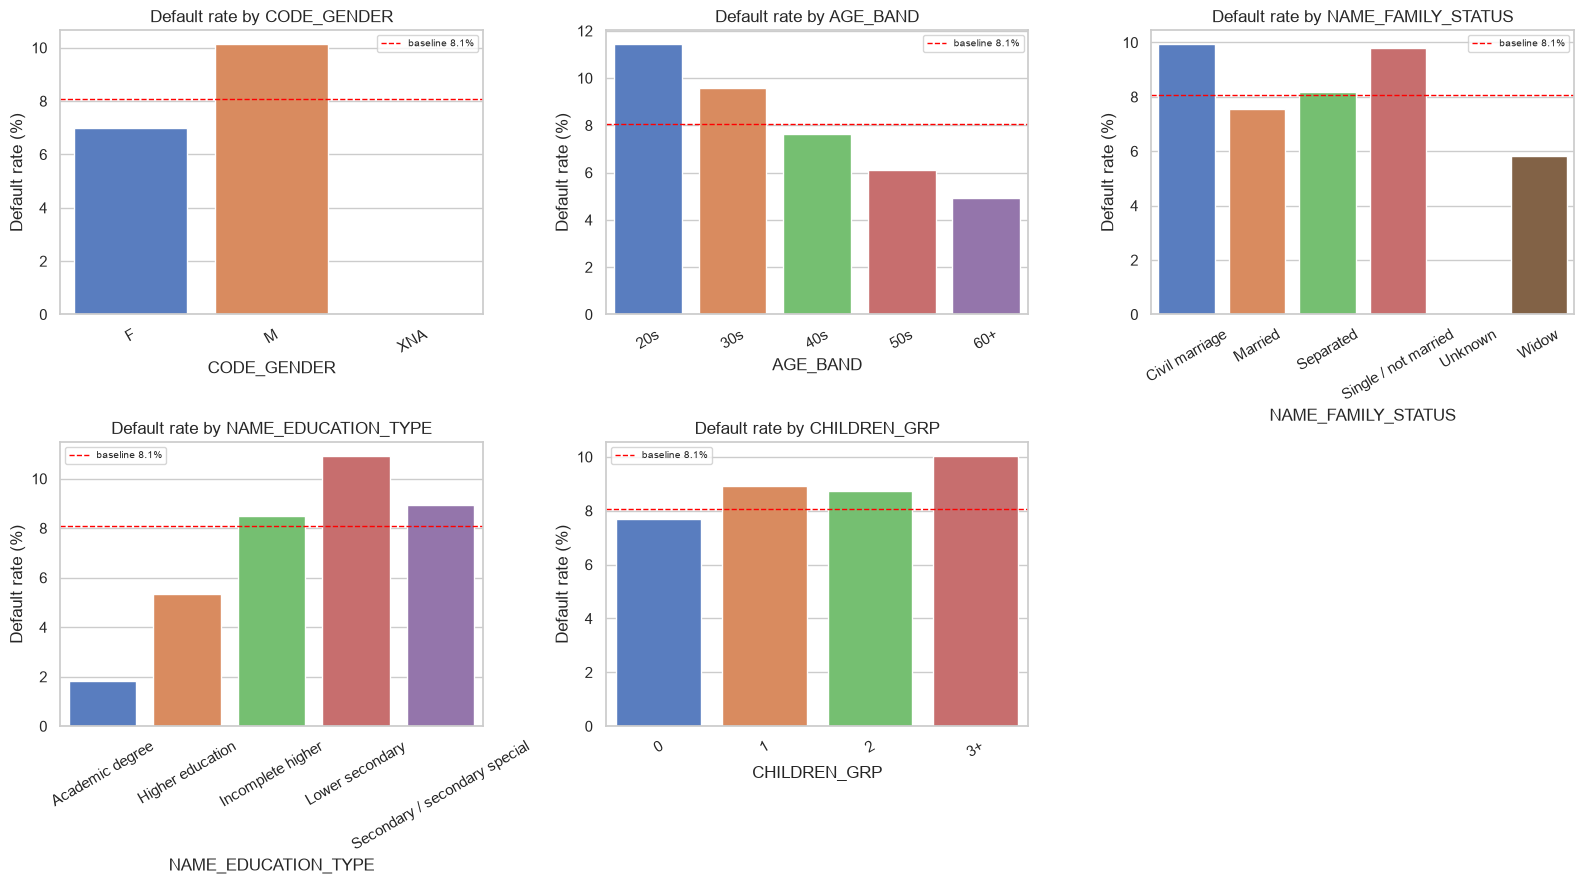

In [6]:
# Derive AGE in years and bucket into bands (age is a protected basis under ECOA).
app["AGE_YEARS"] = -app["DAYS_BIRTH"] / 365.25
app["AGE_BAND"] = pd.cut(app["AGE_YEARS"], [20, 30, 40, 50, 60, 100],
                         labels=["20s", "30s", "40s", "50s", "60+"])

# Cap children for a clean grouping.
app["CHILDREN_GRP"] = app["CNT_CHILDREN"].clip(upper=3).astype(str).replace({"3": "3+"})

baseline = app["TARGET"].mean() * 100
groups = ["CODE_GENDER", "AGE_BAND", "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE", "CHILDREN_GRP"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), groups):
    rate = app.groupby(col)["TARGET"].mean() * 100          # default rate per subgroup
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, palette="muted")
    ax.axhline(baseline, color="red", linestyle="--", linewidth=1, label=f"baseline {baseline:.1f}%")
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default rate (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")     # we have 5 groups in a 2x3 grid; hide the empty 6th panel

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "02_protected_default_rates.png"), dpi=120, bbox_inches="tight")
plt.show()

In [7]:
# Quantify the gap (max - min rate) within each protected attribute — a simple disparity index.
print("Pre-model default-rate disparity by protected attribute:\n")
for col in ["CODE_GENDER", "AGE_BAND", "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE"]:
    rate = app.groupby(col)["TARGET"].mean() * 100
    gap = rate.max() - rate.min()
    print(f"  {col:22s} gap = {gap:5.2f} pp   "
          f"(high: {rate.idxmax()} {rate.max():.1f}% | low: {rate.idxmin()} {rate.min():.1f}%)")

Pre-model default-rate disparity by protected attribute:

  CODE_GENDER            gap = 10.14 pp   (high: M 10.1% | low: XNA 0.0%)
  AGE_BAND               gap =  6.52 pp   (high: 20s 11.4% | low: 60+ 4.9%)
  NAME_FAMILY_STATUS     gap =  9.94 pp   (high: Civil marriage 9.9% | low: Unknown 0.0%)
  NAME_EDUCATION_TYPE    gap =  9.10 pp   (high: Lower secondary 10.9% | low: Academic degree 1.8%)


**Interpretation — the fairness baseline.**
- **Age** has the **largest raw gap**: 20s default **11.4%** vs 60+ **4.9%** (≈6.5 pp).
- **Gender:** M **10.1%** vs F **7.0%** (≈3.1 pp).
- **Education:** ≈9 pp across levels (proxy effect).
- **Family status:** ≈4 pp.

These are **disparities in the data itself**, not yet model behavior. The governance
question the audit answers is: *does the model amplify these gaps, and would acting on
age/gender violate ECOA?* That is why `05` measures **equal-opportunity** and **disparate-impact**
metrics, not just accuracy. The five attributes + their bands defined here are the audit cohort.


## 6 · Correlation among the key numeric features

Before modeling we check for **redundant features** (high mutual correlation), which inflate
variance in linear models and muddy feature-importance interpretation.


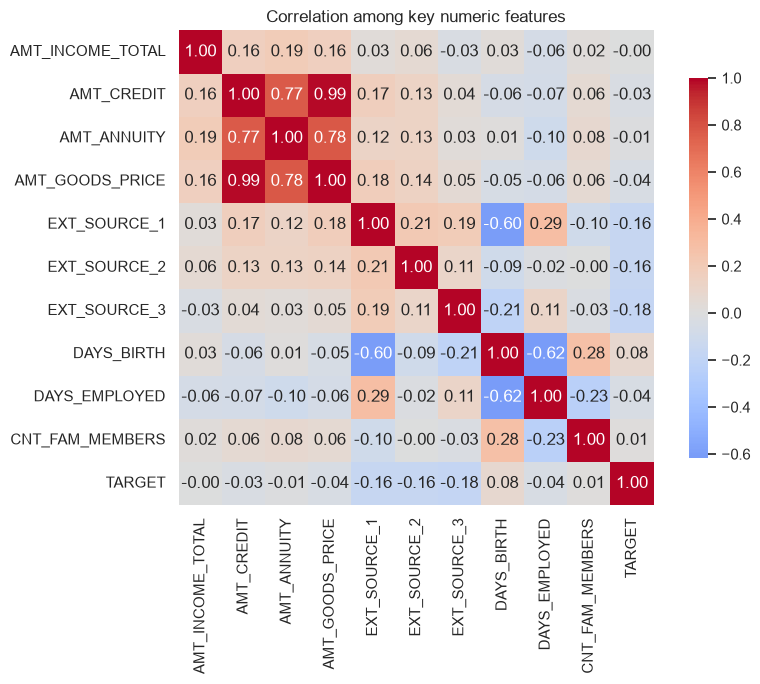

In [8]:
# A compact set of the analytically important numeric features.
key_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
                "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
                "DAYS_BIRTH", "DAYS_EMPLOYED", "CNT_FAM_MEMBERS", "TARGET"]
corr = app[key_features].corr()                             # pairwise Pearson correlation

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation among key numeric features")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "02_feature_correlation.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.**
- **`AMT_CREDIT` and `AMT_GOODS_PRICE` are almost perfectly correlated** (loan amount ≈ price
  of the financed good) → near-duplicate; keep one or build a ratio feature in `03`.
- `AMT_ANNUITY` also tracks `AMT_CREDIT` strongly.
- The three `EXT_SOURCE` scores are **only weakly correlated with each other** → they carry
  *independent* information, so all three are worth keeping.


## 7 · Key takeaways & next step

1. **Strongest predictors:** the three `EXT_SOURCE` scores (independent signals); next, age,
   region ratings, and employment length.
2. **`EXT_SOURCE_1` is ~56% missing** → impute + add was-missing flag (don't drop).
3. **`DAYS_EMPLOYED` sentinel 365243 in 18% of rows** → replace with NaN + anomaly flag.
4. **Redundancy:** `AMT_CREDIT` ≈ `AMT_GOODS_PRICE` → engineer a ratio / drop one.
5. ⭐ **Pre-model disparities:** age (~6.5 pp) > education (~9 pp across levels) > gender
   (~3.1 pp) > family status (~4 pp). These set the **fairness baseline** for `05`.

**Artifacts:** `results/02_corr_with_target.png`, `02_ext_source_by_target.png`,
`02_days_employed_sentinel.png`, `02_categorical_default_rates.png`,
`02_protected_default_rates.png`, `02_feature_correlation.png`.

---
### ➡️ Next: `03_preprocessing_features`
Aggregate the auxiliary tables to one row per applicant, join, apply the fixes above
(sentinel → NaN + flags, leakage-free imputation & scaling fit on train only), and produce
a model-ready matrix — while checking that the cleaning does not introduce subgroup bias.
